# GraphCast 추론 — 통가왕국 (Kingdom of Tonga)

| 항목 | 내용 |
|------|------|
| **모델** | GraphCast (Google DeepMind) |
| **해상도** | 0.25° 전지구 |
| **관심 지점** | Nuku'alofa, Tonga (−21.18°N, −175.20°E) |

## 실행 순서
1. Section 0 → GPU 확인
2. Section 1 → 패키지 설치
3. ⚠️ **런타임 재시작** (필수)
4. Section 2 → 임포트
5. Section 3 → 설정
6. Section 4 → CDS 키 입력
7. Section 5 → GraphCast 추론 (15~20분)
8. Section 6 → 결과 로드
9. Section 7 → 지도 시각화
10. Section 8 → 시계열
11. Section 9 → 웹 데모 서버 + Cloudflare 터널

---
## Section 0: 환경 확인

In [ ]:
import subprocess, sys, os

try:
    import google.colab
    IN_COLAB = True
    print('Environment: Google Colab')
except ImportError:
    IN_COLAB = False
    print('Environment: Local')

r = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total',
                    '--format=csv,noheader'], capture_output=True, text=True)
if r.returncode == 0:
    print(f'GPU: {r.stdout.strip()}')
else:
    print('GPU 없음 — 런타임 > 런타임 유형 변경 > A100 GPU 선택 후 재실행')

Environment: Google Colab
GPU: NVIDIA A100-SXM4-40GB, 40960 MiB


---
## Section 1: 패키지 설치

⚠️ 완료 후 **런타임 재시작** 필요

In [ ]:
import subprocess, sys, os

def apt(pkg):
    subprocess.run(['apt-get', 'install', '-y', '-q', pkg], capture_output=True)

def pip(*pkgs):
    for pkg in pkgs:
        r = subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg],
                           capture_output=True, text=True)
        print(f'  {pkg}: {"OK" if r.returncode == 0 else r.stderr[-80:].strip()}')

print('Installing system libraries...')
subprocess.run(['apt-get', 'update', '-q'], capture_output=True)
for lib in ['libgeos-dev', 'libgeos++-dev', 'libproj-dev',
            'proj-data', 'proj-bin', 'libeccodes-dev']:
    apt(lib)
print('  System libraries: OK')

print('Installing Python packages...')
pip('cartopy', 'cfgrib', 'eccodes', 'ai-models', 'ai-models-graphcast',
    'ecmwf-opendata', 'cdsapi', 'metpy',
    'flask', 'flask-cors', 'flask-socketio',
    'gevent', 'gevent-websocket')

GRAPHCAST_DIR = 'graphcast'
if not os.path.exists(GRAPHCAST_DIR):
    print('Cloning DeepMind GraphCast...')
    r = subprocess.run(['git', 'clone', '-q',
                        'https://github.com/google-deepmind/graphcast.git',
                        GRAPHCAST_DIR], capture_output=True, text=True)
    print('  graphcast:', 'OK' if r.returncode == 0 else r.stderr)
else:
    print('  graphcast already cloned: OK')

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-e',
                f'./{GRAPHCAST_DIR}'], capture_output=True)
print('  graphcast package: OK')

print('Installing JAX (GPU)...')
subprocess.run([sys.executable, '-m', 'pip', 'uninstall', '-q', '-y',
                'jaxlib', 'jax'], capture_output=True)
pip('jaxlib[cuda12]', 'jax[cuda12]', 'dm-haiku',
    'numpy', 'scipy', 'xarray', 'pandas')

print('\nDone! ⚠️ 런타임 재시작 후 Section 2부터 실행하세요.')

Installing system libraries...
  System libraries: OK
Installing Python packages...
  cartopy: OK
  cfgrib: OK
  eccodes: OK
  ai-models: OK
  ai-models-graphcast: OK
  ecmwf-opendata: OK
  cdsapi: OK
  metpy: OK
  flask: OK
  flask-cors: OK
  flask-socketio: OK
  gevent: OK
  gevent-websocket: OK
Cloning DeepMind GraphCast...
  graphcast: OK
  graphcast package: OK
Installing JAX (GPU)...
  jaxlib[cuda12]: OK
  jax[cuda12]: OK
  dm-haiku: OK
  numpy: OK
  scipy: OK
  xarray: OK
  pandas: OK

Done! ⚠️ 런타임 재시작 후 Section 2부터 실행하세요.


In [ ]:
import subprocess, sys

# 호환되는 버전으로 재설치
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'dm-haiku==0.0.12',
                'jax[cuda12]==0.4.30',
                'jaxlib==0.4.30',
                '--force-reinstall'], capture_output=False)

# 확인
import jax, haiku
print(f'jax: {jax.__version__}')
print(f'haiku: {haiku.__version__}')
print(f'devices: {jax.devices()}')

jax: 0.4.30
haiku: 0.0.12
devices: [cuda(id=0)]


---
## Section 2: 임포트 및 초기화

> ⚠️ 런타임 재시작 후 여기서부터 실행

In [ ]:
import os, subprocess, sys
from pathlib import Path
from datetime import datetime

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

GRAPHCAST_DIR = 'graphcast'
if GRAPHCAST_DIR not in sys.path:
    sys.path.insert(0, GRAPHCAST_DIR)
os.environ['PYTHONPATH'] = f'{GRAPHCAST_DIR}:' + os.environ.get('PYTHONPATH', '')

local_bin = os.path.expanduser('~/.local/bin')
if local_bin not in os.environ.get('PATH', ''):
    os.environ['PATH'] = local_bin + ':' + os.environ.get('PATH', '')

_r = subprocess.run(['which', 'ai-models'], capture_output=True, text=True)
AI_MODELS_BIN = _r.stdout.strip() if _r.returncode == 0 else os.path.join(local_bin, 'ai-models')

print(f'ai-models  : {AI_MODELS_BIN}')

try:
    import jax
    print(f'jax        : {jax.__version__}, devices: {jax.devices()}')
except Exception as e:
    print(f'jax ERROR  : {e}')

print('Section 2 완료.')

ai-models  : /usr/local/bin/ai-models
jax        : 0.4.30, devices: [cuda(id=0)]
Section 2 완료.


---
## Section 3: 설정

In [ ]:
# ===== 설정 =====
DATE         = '20260327'  # 초기값 날짜 (YYYYMMDD)
TIME         = '00'        # '00' or '12'
MAX_LEAD_TIME = 120        # 최대 예보 기간 (시간)
LEAD_TIME_STEP = 6         # 예보 간격 (시간)
LEAD_TIME    = 72          # 시각화할 리드타임
INPUT_SOURCE = 'cds'       # 'opendata' or 'cds'

# 통가왕국 중심 좌표
TONGA_LAT  = -21.18
TONGA_LON  = -175.20       # -180~180 표기
TONGA_NAME = "Nuku'alofa, Tonga"

# 시각화 영역
REGION_LAT_MIN = -35.0
REGION_LAT_MAX =  -8.0

OUTPUT_DIR = './graphcast_outputs_tonga'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'날짜      : {DATE} {TIME}Z')
print(f'예보 기간 : +{MAX_LEAD_TIME}h (간격 {LEAD_TIME_STEP}h)')
print(f'시각화    : +{LEAD_TIME}h')
print(f'소스      : {INPUT_SOURCE}')
print(f'관심 지점 : {TONGA_NAME} ({TONGA_LAT}°N, {TONGA_LON}°E)')
print(f'출력 경로 : {OUTPUT_DIR}/')

날짜      : 20260327 00Z
예보 기간 : +120h (간격 6h)
시각화    : +72h
소스      : cds
관심 지점 : Nuku'alofa, Tonga (-21.18°N, -175.2°E)
출력 경로 : ./graphcast_outputs_tonga/


---
## Section 4: CDS API 설정

`INPUT_SOURCE = 'cds'` 사용 시 실행. [CDS 가입](https://cds.climate.copernicus.eu/) 후 토큰 입력.

In [ ]:
if INPUT_SOURCE == 'cds':
    import getpass
    CDS_KEY = getpass.getpass('CDS Personal Access Token: ').strip()
    (Path.home() / '.cdsapirc').write_text(
        f'url: https://cds.climate.copernicus.eu/api\nkey: {CDS_KEY}\n')
    import cdsapi
    try:
        cdsapi.Client(quiet=True)
        print('CDS API: OK')
    except Exception as e:
        print(f'CDS API 실패: {e}')
else:
    print('ECMWF Open Data 사용 — 최근 7일 이내 날짜만 가능')

CDS Personal Access Token: ··········
CDS API: OK


---
## Section 5: GraphCast 추론 실행

**T4 기준 약 15~20분 소요**

In [ ]:
output_path = os.path.join(OUTPUT_DIR, f'graphcast_{DATE}{TIME}.grib')

if os.path.exists(output_path):
    size_mb = os.path.getsize(output_path) / 1e6
    print(f'[SKIP] 기존 파일 사용: {output_path} ({size_mb:.1f} MB)')
else:
    print(f'[RUN] GraphCast +{MAX_LEAD_TIME}h from {DATE} {TIME}Z ...')
    t0 = datetime.now()

    cmd = [
        AI_MODELS_BIN, '--download-assets',
        '--input',  INPUT_SOURCE,
        '--output', 'file',
        '--path',   output_path,
        '--date',   DATE,
        '--time',   TIME,
        '--debug',
        'graphcast'
    ]
    for h in range(0, MAX_LEAD_TIME + LEAD_TIME_STEP, LEAD_TIME_STEP):
        cmd.insert(-1, '--lead-time')
        cmd.insert(-1, str(h))

    result = subprocess.run(cmd, capture_output=True, text=True,
                            timeout=7200, env=os.environ)
    elapsed = int((datetime.now() - t0).total_seconds())

    if result.returncode == 0:
        size_mb = os.path.getsize(output_path) / 1e6
        print(f'완료: {output_path} ({size_mb:.1f} MB, {elapsed//60}분 {elapsed%60}초)')
    else:
        print('실패!')
        print(result.stdout[-3000:])
        print(result.stderr[-3000:])

[RUN] GraphCast +120h from 20260327 00Z ...
완료: ./graphcast_outputs_tonga/graphcast_2026032700.grib (3623.8 MB, 5분 53초)


---
## Section 6: 결과 로드

In [ ]:
import cfgrib, warnings
warnings.filterwarnings('ignore')

VARIABLES = {
    'z500': {'shortName': 'z',   'typeOfLevel': 'isobaricInhPa',     'level': 500},
    't850': {'shortName': 't',   'typeOfLevel': 'isobaricInhPa',     'level': 850},
    't2m':  {'shortName': '2t',  'typeOfLevel': 'heightAboveGround', 'level': 2},
    'u10':  {'shortName': '10u', 'typeOfLevel': 'heightAboveGround', 'level': 10},
    'v10':  {'shortName': '10v', 'typeOfLevel': 'heightAboveGround', 'level': 10},
    'msl':  {'shortName': 'msl', 'typeOfLevel': 'meanSea',           'level': 0},
}

def load_variable(grib_path, var_info, step_hours=None):
    fk = {'shortName': var_info['shortName'], 'typeOfLevel': var_info['typeOfLevel']}
    if var_info['level'] != 0:
        fk['level'] = var_info['level']
    try:
        ds = xr.open_dataset(grib_path, engine='cfgrib',
                             filter_by_keys=fk, indexpath=None)
        da = ds[list(ds.data_vars)[0]]
        if 'step' in da.dims and step_hours is not None:
            da = da.sel(step=np.timedelta64(step_hours, 'h'), method='nearest')
        return da
    except Exception as e:
        print(f'  Warning: {var_info["shortName"]} — {e}')
        return None

gc_data = {}
for var_id, var_info in VARIABLES.items():
    da = load_variable(output_path, var_info, step_hours=LEAD_TIME)
    if da is not None:
        gc_data[var_id] = da
        ln = 'longitude' if 'longitude' in da.dims else 'lon'
        lons = da[ln].values
        print(f'  {var_id}: shape={da.shape}, lon={lons.min():.1f}~{lons.max():.1f}')

# 통가 경도 변환 (0-360 체계 대응)
sample = list(gc_data.values())[0]
ln = 'longitude' if 'longitude' in sample.dims else 'lon'
TONGA_LON_GRIB = TONGA_LON + 360 if sample[ln].values.max() > 180 else TONGA_LON
print(f'\n통가 경도(GRIB): {TONGA_LON_GRIB}°E')
print('Section 6 완료.')

  z500: shape=(721, 1440), lon=0.0~359.8
  t850: shape=(721, 1440), lon=0.0~359.8
  t2m: shape=(721, 1440), lon=0.0~359.8
  u10: shape=(721, 1440), lon=0.0~359.8
  v10: shape=(721, 1440), lon=0.0~359.8
  msl: shape=(721, 1440), lon=0.0~359.8

통가 경도(GRIB): 184.8°E
Section 6 완료.


---
## Section 7: 지도 시각화 (통가 중심, 날짜변경선 수정)

Z500:
  lon: -17.8~17.9 (통가 기준)
  lat: -34.0~-8.2
  shape: (104, 144)


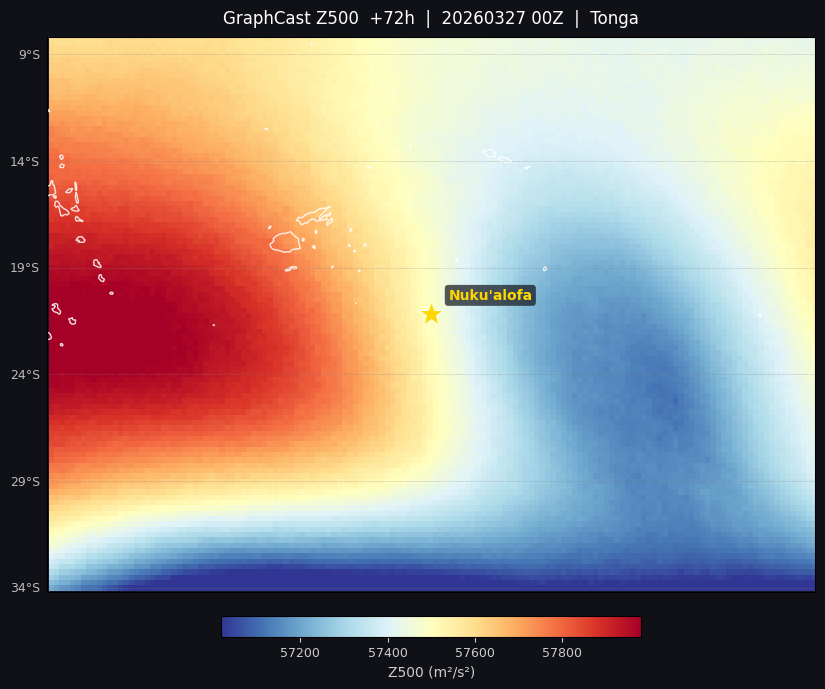

  Saved: ./graphcast_outputs_tonga/GraphCast_Z500__p72h____20260327_00Z____Tonga.png
T2M:
  lon: -17.8~17.9 (통가 기준)
  lat: -34.0~-8.2
  shape: (104, 144)


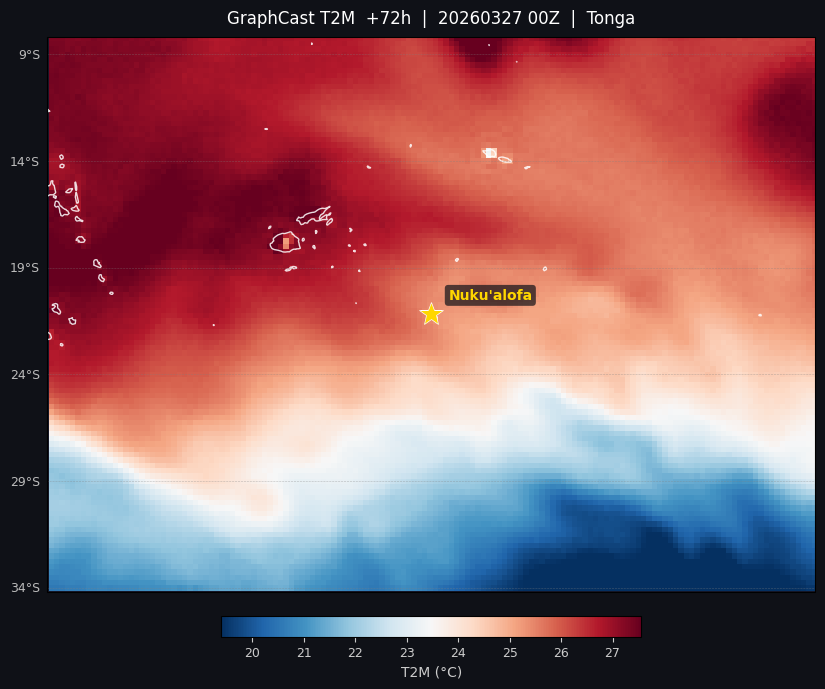

  Saved: ./graphcast_outputs_tonga/GraphCast_T2M__p72h____20260327_00Z____Tonga.png
MSLP + Wind:


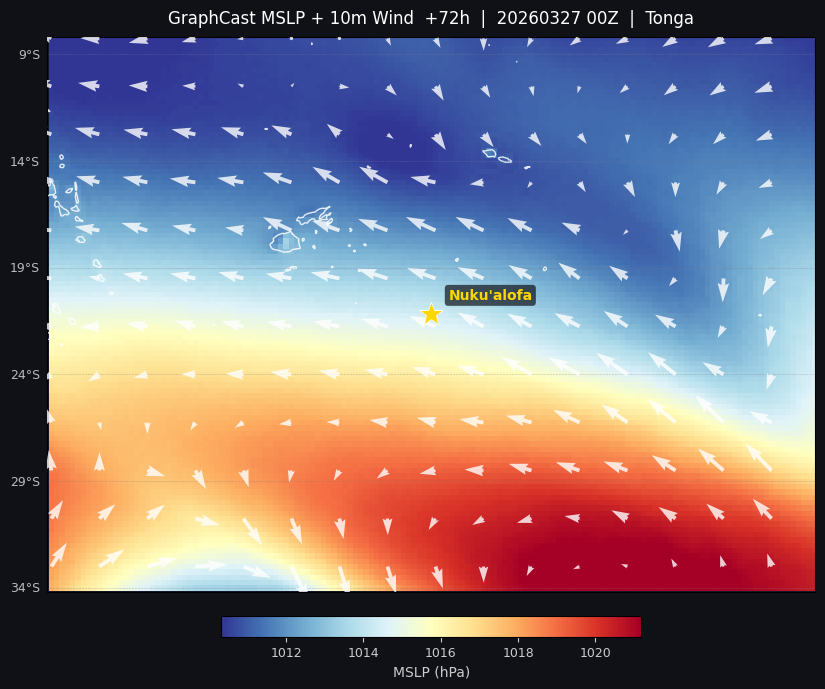

  Saved: ./graphcast_outputs_tonga/graphcast_mslp_wind_tonga_20260327_p72h.png


In [ ]:
import matplotlib.ticker as mticker
warnings.filterwarnings('ignore')

def roll_to_tonga(da):
    """
    GRIB 0-360° DataArray를 통가(-175°E) 중심으로 재정렬.
    반환 경도: 통가 기준 상대값 (0 = 통가)
    """
    lat_name = 'latitude' if 'latitude' in da.dims else 'lat'
    lon_name = 'longitude' if 'longitude' in da.dims else 'lon'
    lons = da[lon_name].values.copy()
    lats = da[lat_name].values.copy()
    vals = da.values.copy()

    TONGA_LON_360 = TONGA_LON + 360  # -175.2 → 184.8
    lons_rel = lons - TONGA_LON_360
    lons_rel = np.where(lons_rel >  180, lons_rel - 360, lons_rel)
    lons_rel = np.where(lons_rel < -180, lons_rel + 360, lons_rel)

    sort_idx   = np.argsort(lons_rel)
    lons_sorted = lons_rel[sort_idx]
    vals_sorted = vals[:, sort_idx] if vals.ndim == 2 else vals[sort_idx]
    return lons_sorted, lats, vals_sorted


def plot_field_tonga(da, title, label, cmap='RdYlBu_r',
                     convert_fn=None, half_lon=18, half_lat=13):
    lons, lats, vals = roll_to_tonga(da)
    if convert_fn is not None:
        vals = convert_fn(vals)

    lat_mask = (lats >= TONGA_LAT - half_lat) & (lats <= TONGA_LAT + half_lat)
    lon_mask = (lons >= -half_lon) & (lons <= half_lon)
    lats_r = lats[lat_mask]
    lons_r = lons[lon_mask]
    vals_r = vals[np.ix_(lat_mask, lon_mask)]

    print(f'  lon: {lons_r.min():.1f}~{lons_r.max():.1f} (통가 기준)')
    print(f'  lat: {lats_r.min():.1f}~{lats_r.max():.1f}')
    print(f'  shape: {vals_r.shape}')

    lon2d, lat2d = np.meshgrid(lons_r, lats_r)

    proj      = ccrs.PlateCarree(central_longitude=TONGA_LON)
    data_proj = ccrs.PlateCarree(central_longitude=TONGA_LON)

    fig, ax = plt.subplots(figsize=(10, 7),
                           subplot_kw={'projection': proj},
                           facecolor='#0f1117')
    ax.set_facecolor('#1a1a2e')

    vmin, vmax = np.nanpercentile(vals_r, [2, 98])
    im = ax.pcolormesh(lon2d, lat2d, vals_r,
                       cmap=cmap, vmin=vmin, vmax=vmax,
                       transform=data_proj, shading='auto')

    ax.add_feature(cfeature.COASTLINE, linewidth=1.0, color='white', alpha=0.85)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, color='white', alpha=0.4)
    ax.add_feature(cfeature.LAND,      facecolor='#1e1e30', alpha=0.5, zorder=0)
    ax.add_feature(cfeature.OCEAN,     facecolor='#0d1620', alpha=0.3, zorder=0)

    ax.set_extent([-half_lon, half_lon,
                   TONGA_LAT - half_lat, TONGA_LAT + half_lat],
                  crs=data_proj)

    gl = ax.gridlines(draw_labels=True, linewidth=0.4,
                      color='gray', alpha=0.5, linestyle='--',
                      x_inline=False, y_inline=False)
    gl.top_labels   = False
    gl.right_labels = False
    gl.xlocator = mticker.FixedLocator(list(range(-15, 16, 5)))
    gl.ylocator = mticker.FixedLocator(
        list(range(int(TONGA_LAT - half_lat), int(TONGA_LAT + half_lat) + 1, 5)))
    gl.xlabel_style = {'size': 9, 'color': '#bbb'}
    gl.ylabel_style = {'size': 9, 'color': '#bbb'}

    ax.plot(0, TONGA_LAT, marker='*', markersize=18,
            color='#FFD700', transform=data_proj,
            markeredgecolor='white', markeredgewidth=0.5,
            zorder=10, linestyle='None')
    ax.text(0.8, TONGA_LAT + 0.7, "Nuku'alofa",
            color='#FFD700', fontsize=10, fontweight='bold',
            transform=data_proj, zorder=11,
            bbox=dict(boxstyle='round,pad=0.25', facecolor='#0f1117',
                      alpha=0.7, edgecolor='none'))

    cbar = plt.colorbar(im, ax=ax, orientation='horizontal',
                        pad=0.04, fraction=0.035)
    cbar.ax.tick_params(labelsize=9, colors='#ccc')
    cbar.set_label(label, color='#ccc', fontsize=10)

    ax.set_title(title, fontsize=12, pad=10, color='white')
    fig.patch.set_facecolor('#0f1117')
    plt.tight_layout()

    safe = (title.replace(' ', '_').replace('/', '')
                 .replace('²','2').replace('+','p').replace('|',''))
    fname = f'{OUTPUT_DIR}/{safe}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='#0f1117')
    plt.show()
    print(f'  Saved: {fname}')


# Z500
if 'z500' in gc_data:
    print('Z500:')
    plot_field_tonga(
        gc_data['z500'],
        f'GraphCast Z500  +{LEAD_TIME}h  |  {DATE} {TIME}Z  |  Tonga',
        'Z500 (m²/s²)', cmap='RdYlBu_r')

# T2M
if 't2m' in gc_data:
    print('T2M:')
    plot_field_tonga(
        gc_data['t2m'],
        f'GraphCast T2M  +{LEAD_TIME}h  |  {DATE} {TIME}Z  |  Tonga',
        'T2M (°C)', cmap='RdBu_r',
        convert_fn=lambda v: v - 273.15)

# MSLP + Wind
if all(v in gc_data for v in ['msl', 'u10', 'v10']):
    print('MSLP + Wind:')
    HALF_LON = 18
    HALF_LAT = 13
    lons, lats, msl_r = roll_to_tonga(gc_data['msl'])
    _,    _,    u_r   = roll_to_tonga(gc_data['u10'])
    _,    _,    v_r   = roll_to_tonga(gc_data['v10'])

    lat_mask = (lats >= TONGA_LAT - HALF_LAT) & (lats <= TONGA_LAT + HALF_LAT)
    lon_mask = (lons >= -HALF_LON) & (lons <= HALF_LON)
    idx = np.ix_(lat_mask, lon_mask)
    lats_r = lats[lat_mask]
    lons_r = lons[lon_mask]
    msl_r  = msl_r[idx] / 100.0
    u_r    = u_r[idx]
    v_r    = v_r[idx]
    lon2d, lat2d = np.meshgrid(lons_r, lats_r)

    proj = data_proj = ccrs.PlateCarree(central_longitude=TONGA_LON)
    fig, ax = plt.subplots(figsize=(10, 7),
                           subplot_kw={'projection': proj},
                           facecolor='#0f1117')
    ax.set_facecolor('#1a1a2e')
    vmin, vmax = np.nanpercentile(msl_r, [2, 98])
    im = ax.pcolormesh(lon2d, lat2d, msl_r, cmap='RdYlBu_r',
                       vmin=vmin, vmax=vmax, transform=data_proj, shading='auto')
    step = max(1, lon2d.shape[1] // 16)
    ax.quiver(lon2d[::step, ::step], lat2d[::step, ::step],
              u_r[::step, ::step],   v_r[::step, ::step],
              transform=data_proj, scale=200, width=0.005,
              color='white', alpha=0.8, zorder=5)
    ax.add_feature(cfeature.COASTLINE, linewidth=1.0, color='white', alpha=0.85)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, color='white', alpha=0.4)
    ax.add_feature(cfeature.LAND,      facecolor='#1e1e30', alpha=0.5)
    ax.add_feature(cfeature.OCEAN,     facecolor='#0d1620', alpha=0.3)
    ax.set_extent([-HALF_LON, HALF_LON,
                   TONGA_LAT - HALF_LAT, TONGA_LAT + HALF_LAT], crs=data_proj)
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray',
                      alpha=0.5, linestyle='--', x_inline=False, y_inline=False)
    gl.top_labels = False; gl.right_labels = False
    gl.xlocator = mticker.FixedLocator(list(range(-15, 16, 5)))
    gl.ylocator = mticker.FixedLocator(
        list(range(int(TONGA_LAT - HALF_LAT), int(TONGA_LAT + HALF_LAT) + 1, 5)))
    gl.xlabel_style = {'size': 9, 'color': '#bbb'}
    gl.ylabel_style = {'size': 9, 'color': '#bbb'}
    ax.plot(0, TONGA_LAT, marker='*', markersize=18, color='#FFD700',
            transform=data_proj, markeredgecolor='white',
            markeredgewidth=0.5, zorder=10, linestyle='None')
    ax.text(0.8, TONGA_LAT + 0.7, "Nuku'alofa", color='#FFD700',
            fontsize=10, fontweight='bold', transform=data_proj, zorder=11,
            bbox=dict(boxstyle='round,pad=0.25', facecolor='#0f1117',
                      alpha=0.7, edgecolor='none'))
    cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.04, fraction=0.035)
    cbar.ax.tick_params(labelsize=9, colors='#ccc')
    cbar.set_label('MSLP (hPa)', color='#ccc', fontsize=10)
    ax.set_title(
        f'GraphCast MSLP + 10m Wind  +{LEAD_TIME}h  |  {DATE} {TIME}Z  |  Tonga',
        fontsize=12, pad=10, color='white')
    fig.patch.set_facecolor('#0f1117')
    plt.tight_layout()
    fname = f'{OUTPUT_DIR}/graphcast_mslp_wind_tonga_{DATE}_p{LEAD_TIME}h.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='#0f1117')
    plt.show()
    print(f'  Saved: {fname}')

---
## Section 8: 시계열 — Nuku'alofa T2M

격자 지점: -21.25°N, -175.25°E


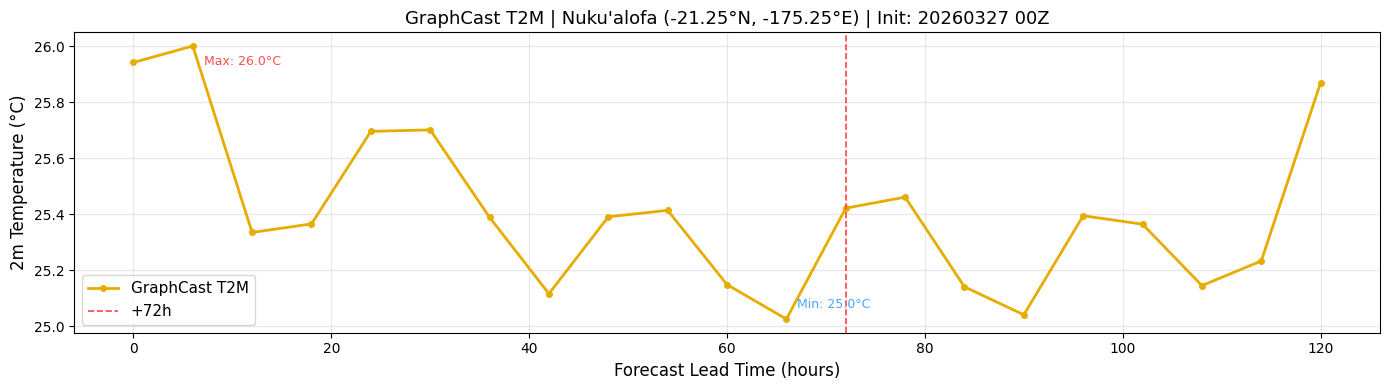

Saved: ./graphcast_outputs_tonga/graphcast_timeseries_t2m_tonga_20260327.png


In [ ]:
try:
    ds_all = xr.open_dataset(output_path, engine='cfgrib',
                             filter_by_keys={'shortName': '2t',
                                             'typeOfLevel': 'heightAboveGround',
                                             'level': 2},
                             indexpath=None)
    vname = list(ds_all.data_vars)[0]
    da    = ds_all[vname]

    lat_name = 'latitude' if 'latitude' in da.dims else 'lat'
    lon_name = 'longitude' if 'longitude' in da.dims else 'lon'

    ts = da.sel({lat_name: TONGA_LAT, lon_name: TONGA_LON_GRIB},
                method='nearest') - 273.15

    actual_lat = float(ts[lat_name].values)
    actual_lon = float(ts[lon_name].values)
    actual_lon_d = actual_lon - 360 if actual_lon > 180 else actual_lon
    print(f'격자 지점: {actual_lat:.2f}°N, {actual_lon_d:.2f}°E')

    if 'step' in ts.dims or 'step' in ts.coords:
        steps_h = np.atleast_1d(ts['step'].values).astype('timedelta64[h]').astype(float)
        vals    = np.atleast_1d(ts.values)

        fig, ax = plt.subplots(figsize=(14, 4))
        ax.plot(steps_h, vals, '-o', markersize=4, linewidth=2,
                color='#E6AC00', label='GraphCast T2M')
        ax.axvline(LEAD_TIME, color='#FF4444', linestyle='--',
                   linewidth=1.2, label=f'+{LEAD_TIME}h')
        ax.set_xlabel('Forecast Lead Time (hours)', fontsize=12)
        ax.set_ylabel('2m Temperature (°C)', fontsize=12)
        ax.set_title(
            f"GraphCast T2M | Nuku'alofa ({actual_lat:.2f}°N, {actual_lon_d:.2f}°E)"
            f" | Init: {DATE} {TIME}Z", fontsize=13)
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.annotate(f'Min: {vals.min():.1f}°C',
                    xy=(steps_h[vals.argmin()], vals.min()),
                    xytext=(8, 8), textcoords='offset points',
                    fontsize=9, color='#4da6ff')
        ax.annotate(f'Max: {vals.max():.1f}°C',
                    xy=(steps_h[vals.argmax()], vals.max()),
                    xytext=(8, -14), textcoords='offset points',
                    fontsize=9, color='#ff4d4d')
        plt.tight_layout()
        fname = f'{OUTPUT_DIR}/graphcast_timeseries_t2m_tonga_{DATE}.png'
        plt.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved: {fname}')

except Exception as e:
    import traceback
    print(f'실패: {e}')
    traceback.print_exc()

---
## Section 9: 웹 데모 서버 + Cloudflare 터널

Flask + SocketIO 서버를 시작하고 Cloudflare로 외부 URL을 만듭니다.
출력된 URL을 `graphcast_demo_v2.html` 상단에 붙여넣으면 됩니다.

In [ ]:
# ── 패키지 확인 ───────────────────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'flask', 'flask-cors', 'flask-socketio',
                'gevent', 'gevent-websocket'], capture_output=True)

# ── gevent monkey_patch (제일 먼저) ───────────────────────────────────────────
from gevent import monkey
monkey.patch_all()

import os, json, threading, warnings, time
from pathlib import Path
from datetime import datetime
import numpy as np
import xarray as xr
import cfgrib
warnings.filterwarnings('ignore')

from flask import Flask, jsonify, request
from flask_cors import CORS
from flask_socketio import SocketIO, emit

# ── 변수 정의 ─────────────────────────────────────────────────────────────────
VARIABLES_API = {
    'z500': {'shortName': 'z',   'typeOfLevel': 'isobaricInhPa',     'level': 500, 'label': 'Z500 (m²/s²)', 'unit': 'm²/s²'},
    't850': {'shortName': 't',   'typeOfLevel': 'isobaricInhPa',     'level': 850, 'label': 'T850 (K)',     'unit': 'K'},
    't2m':  {'shortName': '2t',  'typeOfLevel': 'heightAboveGround', 'level': 2,   'label': 'T2M (°C)',     'unit': '°C'},
    'u10':  {'shortName': '10u', 'typeOfLevel': 'heightAboveGround', 'level': 10,  'label': 'U10 (m/s)',    'unit': 'm/s'},
    'v10':  {'shortName': '10v', 'typeOfLevel': 'heightAboveGround', 'level': 10,  'label': 'V10 (m/s)',    'unit': 'm/s'},
    'msl':  {'shortName': 'msl', 'typeOfLevel': 'meanSea',           'level': 0,   'label': 'MSLP (hPa)',   'unit': 'hPa'},
}

_state = {
    'running':   False,
    'grib_path': output_path if os.path.exists(output_path) else None,
    'date':      DATE,
    'time':      TIME,
}
_cache = {}

# ── Flask + SocketIO ──────────────────────────────────────────────────────────
app = Flask(__name__)
app.config['SECRET_KEY'] = 'graphcast-tonga'
CORS(app, resources={r'/*': {'origins': '*'}})
sio = SocketIO(app, cors_allowed_origins='*', async_mode='gevent',
               logger=False, engineio_logger=False)


@sio.on('connect')
def on_connect():
    has_data = bool(_state['grib_path'] and os.path.exists(_state['grib_path']))
    emit('status', {
        'running': _state['running'], 'has_data': has_data,
        'date': _state['date'], 'time': _state['time'],
    })


@sio.on('run_inference')
def on_run_inference(data):
    if _state['running']:
        emit('log', {'level': 'warn', 'msg': '이미 실행 중'}); return

    date      = data.get('date', DATE)
    time_     = data.get('time', TIME)
    max_lead  = int(data.get('max_lead', 120))
    lead_step = int(data.get('step', 6))
    source    = data.get('source', 'cds')
    cds_key   = data.get('cds_key', '').strip()
    grib_path = os.path.join(OUTPUT_DIR, f'graphcast_{date}{time_}.grib')

    if source == 'cds':
        if not cds_key:
            emit('log', {'level': 'error', 'msg': 'CDS 키 없음'})
            emit('inference_failed', {'reason': 'No CDS key'}); return
        (Path.home() / '.cdsapirc').write_text(
            f'url: https://cds.climate.copernicus.eu/api\nkey: {cds_key}\n')

    if os.path.exists(grib_path):
        size_mb = os.path.getsize(grib_path) / 1e6
        _state.update({'grib_path': grib_path, 'date': date, 'time': time_})
        _cache.clear()
        emit('log', {'level': 'info', 'msg': f'기존 파일 사용: {size_mb:.1f} MB'})
        emit('inference_done', {'grib': grib_path, 'date': date,
                                'time': time_, 'size_mb': round(size_mb, 1)}); return

    cmd = [AI_MODELS_BIN, '--download-assets',
           '--input', source, '--output', 'file',
           '--path', grib_path, '--date', date, '--time', time_, 'graphcast']
    for h in range(0, max_lead + lead_step, lead_step):
        cmd.insert(-1, '--lead-time'); cmd.insert(-1, str(h))

    def _run():
        _state.update({'running': True, 'date': date, 'time': time_})
        _cache.clear()
        sio.emit('inference_started', {'date': date, 'time': time_})
        sio.emit('progress', {'pct': 3, 'msg': '초기장 준비 중...'})
        t0 = datetime.now()
        total = max_lead // lead_step
        step_count = 0
        proc = subprocess.Popen(cmd, stdout=subprocess.PIPE,
                                stderr=subprocess.STDOUT,
                                text=True, env=os.environ, bufsize=1)
        for line in proc.stdout:
            line = line.rstrip()
            if not line: continue
            low = line.lower()
            if 'downloading' in low or 'fetching' in low:
                sio.emit('progress', {'pct': 8, 'msg': '다운로드 중...'})
                sio.emit('log', {'level': 'info', 'msg': line})
            elif 'step' in low and any(c.isdigit() for c in line):
                step_count += 1
                pct = 15 + int(80 * step_count / max(total, 1))
                sio.emit('progress', {'pct': min(pct, 94), 'msg': line.strip()})
                sio.emit('log', {'level': 'step', 'msg': line})
            elif 'error' in low:
                sio.emit('log', {'level': 'error', 'msg': line})
            else:
                sio.emit('log', {'level': 'info', 'msg': line})
        proc.wait()
        elapsed = int((datetime.now() - t0).total_seconds())
        if proc.returncode == 0 and os.path.exists(grib_path):
            size_mb = os.path.getsize(grib_path) / 1e6
            _state['grib_path'] = grib_path
            sio.emit('progress', {'pct': 100, 'msg': '완료!'})
            sio.emit('log', {'level': 'success',
                              'msg': f'완료: {size_mb:.1f} MB · {elapsed//60}분 {elapsed%60}초'})
            sio.emit('inference_done', {'grib': grib_path, 'date': date,
                                        'time': time_, 'size_mb': round(size_mb,1),
                                        'elapsed': elapsed})
        else:
            sio.emit('progress', {'pct': 0, 'msg': '실패'})
            sio.emit('inference_failed', {'reason': f'rc={proc.returncode}'})
        _state['running'] = False

    threading.Thread(target=_run, daemon=True).start()


# ── REST API ──────────────────────────────────────────────────────────────────
def _load_var(var_id):
    if var_id in _cache: return _cache[var_id]
    grib = _state['grib_path']
    if not grib or not os.path.exists(grib): return None
    info = VARIABLES_API[var_id]
    fk = {'shortName': info['shortName'], 'typeOfLevel': info['typeOfLevel']}
    if info['level'] != 0: fk['level'] = info['level']
    try:
        ds = xr.open_dataset(grib, engine='cfgrib', filter_by_keys=fk, indexpath=None)
        da = ds[list(ds.data_vars)[0]]
        _cache[var_id] = da; return da
    except Exception as e:
        print(f'Load error {var_id}: {e}'); return None

def _slice(da, lat_c, lon_c, half=12.0):
    ln = 'longitude' if 'longitude' in da.dims else 'lon'
    la = 'latitude'  if 'latitude'  in da.dims else 'lat'
    lons = da[ln].values; lats = da[la].values
    lon_q = lon_c + 360 if lon_c < 0 and lons.max() > 180 else lon_c
    lat_m = (lats >= lat_c - half) & (lats <= lat_c + half)
    lon_m = (lons >= lon_q - half) & (lons <= lon_q + half)
    lats_r = lats[lat_m]
    lons_r = lons[lon_m] - (360 if lons.max() > 180 else 0)
    if 'step' in da.dims:
        steps = da['step'].values.astype('timedelta64[h]').astype(float)
        vals  = da.values[:, lat_m, :][:, :, lon_m]
    else:
        steps = np.array([0.0])
        vals  = da.values[lat_m, :][:, lon_m][np.newaxis]
    return {'lats': lats_r.tolist(), 'lons': lons_r.tolist(),
            'steps_h': steps.tolist(), 'values': vals.tolist()}

@app.route('/info')
def api_info():
    has = bool(_state['grib_path'] and os.path.exists(_state['grib_path'] or ''))
    return jsonify({
        'running': _state['running'], 'has_data': has,
        'date': _state['date'], 'time': _state['time'],
        'grib': os.path.basename(_state['grib_path']) if has else None,
        'variables': {k: {'label': v['label'], 'unit': v['unit']}
                      for k, v in VARIABLES_API.items()},
    })

@app.route('/forecast')
def api_forecast():
    lat  = float(request.args.get('lat', TONGA_LAT))
    lon  = float(request.args.get('lon', TONGA_LON))
    var  = request.args.get('var', 't2m')
    half = float(request.args.get('half', 12.0))
    step = request.args.get('step', None)
    if var not in VARIABLES_API: return jsonify({'error': f'Unknown: {var}'}), 400
    da = _load_var(var)
    if da is None: return jsonify({'error': '데이터 없음'}), 404
    r = _slice(da, lat, lon, half)
    if var == 't2m': r['values'] = (np.array(r['values']) - 273.15).tolist()
    if var == 'msl': r['values'] = (np.array(r['values']) / 100.0).tolist()
    if step is not None:
        idx = int(np.argmin(np.abs(np.array(r['steps_h']) - float(step))))
        r['values'] = [r['values'][idx]]; r['steps_h'] = [r['steps_h'][idx]]
    r.update({'var': var, 'label': VARIABLES_API[var]['label'],
              'unit': VARIABLES_API[var]['unit'],
              'date': f"{_state['date']} {_state['time']}Z",
              'center': {'lat': lat, 'lon': lon}})
    return jsonify(r)

@app.route('/timeseries')
def api_timeseries():
    lat = float(request.args.get('lat', TONGA_LAT))
    lon = float(request.args.get('lon', TONGA_LON))
    var = request.args.get('var', 't2m')
    if var not in VARIABLES_API: return jsonify({'error': f'Unknown: {var}'}), 400
    da = _load_var(var)
    if da is None: return jsonify({'error': '데이터 없음'}), 404
    ln = 'longitude' if 'longitude' in da.dims else 'lon'
    la = 'latitude'  if 'latitude'  in da.dims else 'lat'
    lons = da[ln].values
    lon_q = lon + 360 if lon < 0 and lons.max() > 180 else lon
    pt = da.sel({la: lat, ln: lon_q}, method='nearest')
    if var == 't2m': pt = pt - 273.15
    if var == 'msl': pt = pt / 100.0
    if 'step' in pt.dims or 'step' in pt.coords:
        steps  = np.atleast_1d(pt['step'].values).astype('timedelta64[h]').astype(float)
        values = np.atleast_1d(pt.values).tolist()
    else:
        steps = np.array([0.0]); values = [float(pt.values)]
    return jsonify({
        'var': var, 'label': VARIABLES_API[var]['label'],
        'unit': VARIABLES_API[var]['unit'],
        'date': f"{_state['date']} {_state['time']}Z",
        'point': {'lat': float(pt[la].values),
                  'lon': float(pt[ln].values) - (360 if lons.max() > 180 else 0)},
        'steps_h': steps.tolist(), 'values': values,
    })


# ── Flask 서버 시작 ───────────────────────────────────────────────────────────
def _serve():
    from gevent import pywsgi
    from geventwebsocket.handler import WebSocketHandler
    server = pywsgi.WSGIServer(('0.0.0.0', 5000), app,
                                handler_class=WebSocketHandler)
    server.serve_forever()

print('Flask 서버 시작 중...')
threading.Thread(target=_serve, daemon=True).start()
time.sleep(2)
print('Flask 서버 실행 중 (port 5000)')

Flask 서버 시작 중...
Flask 서버 실행 중 (port 5000)


In [ ]:
# ── Cloudflare 터널 ───────────────────────────────────────────────────────────
import subprocess, time

# cloudflared 다운로드
subprocess.run(
    ['wget', '-q',
     'https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64',
     '-O', 'cloudflared'],
    check=True)
subprocess.run(['chmod', '+x', 'cloudflared'], check=True)
print('cloudflared 다운로드 완료')

# 터널 시작
proc = subprocess.Popen(
    ['./cloudflared', 'tunnel', '--url', 'http://localhost:5000'],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

PUBLIC_URL = None
for _ in range(30):
    line = proc.stdout.readline()
    if 'trycloudflare.com' in line:
        import re
        match = re.search(r'https://[\w\-]+\.trycloudflare\.com', line)
        if match:
            PUBLIC_URL = match.group(0)
            break
    time.sleep(1)

if PUBLIC_URL:
    print(f'\n{"="*55}')
    print(f'  웹 데모 준비 완료!')
    print(f'  URL: {PUBLIC_URL}')
    print(f'{"="*55}')
    print(f'\n  → graphcast_demo_v2.html 열고 위 URL 붙여넣기')
    print(f'  → 날짜/설정 입력 후 [추론 실행] 클릭')
else:
    print('URL 자동 감지 실패. 아래 셀을 실행하세요:')
    print('  !./cloudflared tunnel --url http://localhost:5000')

cloudflared 다운로드 완료

  웹 데모 준비 완료!
  URL: https://trees-seniors-topic-testament.trycloudflare.com

  → graphcast_demo_v2.html 열고 위 URL 붙여넣기
  → 날짜/설정 입력 후 [추론 실행] 클릭
